In [1]:
# Micrograd is a tiny scalar-valued automatic differentiation (autograd) engine created by Andrej Karpathy. 
# It's designed primarily as an educational tool to demystify how neural networks and backpropagation work under the hood.

In [2]:
pip install micrograd

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Data structure to maintain mathematical expressions for neural network
import math
class Value:
    def __init__(self, data, _children=(), _op ='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    # Providing a way to print
    def __repr__(self):
        return f"Value(data={self.data})"
   
    # methods in python should start with double underscore to define operators for objects
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
   
    # Activation function for NN, we are using hyperbolic function here 
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out 

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1
        for node in reversed(topo):
            node._backward()
a = Value(-3.0, label='a')
b = Value(-2.0, label='b')
c = Value(10.0, label='c')
# Addition
# Python  internally interprets/calls as a.__add__(b). So, a will be self, and b will be other
# Multiplication
# Python will interpret as (a.__mul__(b)).__add__(c)
# d = a*b + c
# d._prev
# d._op

# Childern in this example is the result of a*b(because it creates one value) and c.

# op is is the field which finds/shows how a value is created i.e, the operator.
# In the case of value by a*b, the value, op is *.

e = a * b; e.label='e'
d = e + c; d.label='d'
f = Value(-2.0, label='f')

L = d * f; L.label='L'
L


Value(data=-32.0)

In [4]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
          # For graph purpose, child is going into/feeding into parent
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

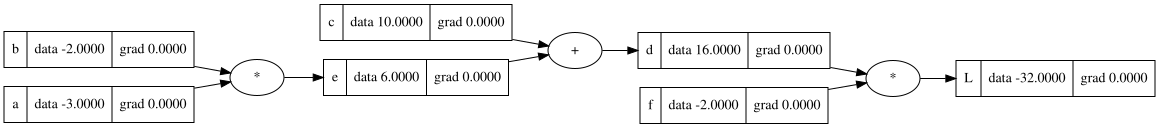

In [5]:
draw_dot(L)

In [6]:
# Experiment with gradient in NN
def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()

-3.9999999999995595


In [7]:
# NN implementation with weights, bias and activation function

# Neuron has inputs associated with weights, 
# whose product are added with bias and passed on to activation function

# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of a neuron
b = Value(6.8813735870195432, label='b')

# x1*w1+x2*w2+b
x1w1= x1*w1;x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2;x1w1x2w2.label='x1w1+x2w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh();o.label='o'


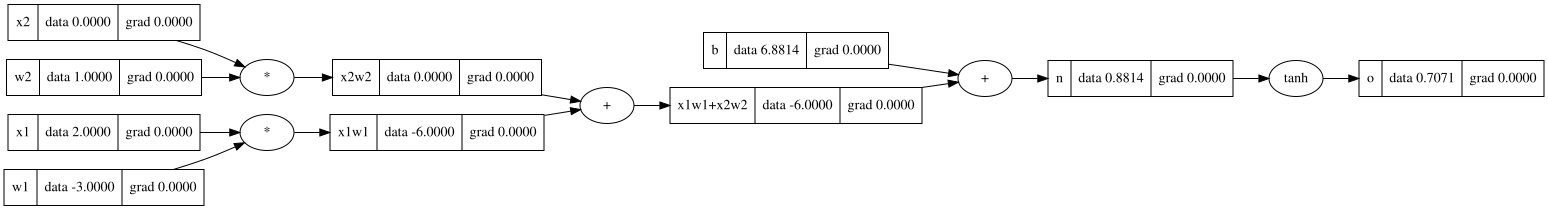

In [8]:
draw_dot(o)

In [9]:
# # Backpropogation through tanh - Manual calculation
# o.grad = 1.0
# # do/dn = 1 - o**2
# n.grad = 1 - o.data**2

# # Check the calculations in your notes to see how these grad are calculated
# x1w1x2w2.grad = 0.5
# b.grad = 0.5

# #
# x1w1.grad = 0.5
# x2w2.grad = 0.5

# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data + x2w2.grad

# x1.grad = w1.data + x1w1.grad
# w1.grad = w1.data + x1w1.grad

# # manually callin n_backward()
# n._backward()

# # calling the new backward function
# o.backward()

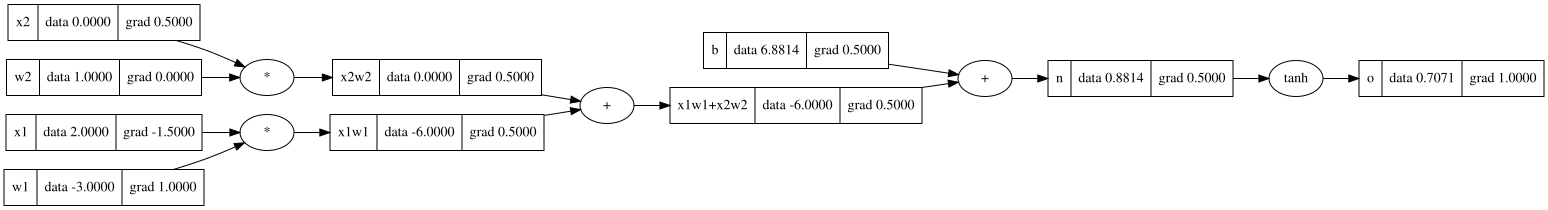

In [10]:
# calling the new backward function
o.backward()
draw_dot(o)